# Bước 01 — Forward diffusion (thêm nhiễu dần vào ảnh)

Notebook giải thích từng phần của [`01_forward_process.py`](./01_forward_process.py).

**Mục tiêu:** Hiểu *forward process* — cách diffusion **phá ảnh đẹp thành nhiễu** theo từng bước thời gian `t`.

| Khái niệm | Ý nghĩa nhanh |
|-----------|----------------|
| `x_0` | Ảnh gốc (sạch) |
| `x_t` | Ảnh ở bước thời gian `t` (càng lớn `t` → càng nhiễu) |
| `T = 1000` | Tổng số mức nhiễu (schedule) |
| `alpha_bar_t` | Tỉ lệ **tín hiệu ảnh gốc còn lại** (1 → 0) |

**Chạy notebook:** kernel Python 3.10+ · cài deps: `pip install -r requirements.txt` · chạy **tuần tự từ trên xuống**.

> Liên hệ SwiftEdit: pipeline chỉnh sửa chạy **ngược** hướng này (denoise). Muốn edit ảnh cũ, method cũ phải **invert** (tìm noise) — SwiftEdit học `F_theta` làm việc đó trong 1 bước.

## 0. Setup — đường dẫn & import

Notebook phải chạy từ thư mục `learn/diffusion-from-scratch/` (cùng cấp với `diffusion/`).

In [1]:
%matplotlib inline

import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "diffusion" / "schedule.py").exists():
    raise FileNotFoundError(
        f"Không thấy diffusion/schedule.py trong {ROOT}.\n"
        "Mở notebook từ thư mục learn/diffusion-from-scratch/ hoặc cd vào đó trước."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

from diffusion.schedule import LinearSchedule
from diffusion.utils import set_seed

set_seed(42)
print("ROOT:", ROOT)
print("PyTorch:", torch.__version__)

ROOT: /Users/nguyenkz/Documents/code/CS2309.CH201/learn/diffusion-from-scratch
PyTorch: 2.12.0


## 1. Ảnh gốc `x_0` — lấy một chữ số MNIST

**Forward process** luôn bắt đầu từ ảnh thật `x_0`.

- MNIST: ảnh xám 28×28, pixel `[0, 1]` sau `ToTensor()`
- Diffusion paper thường scale về **`[-1, 1]`**: `x = tensor * 2 - 1`
- Script gốc lấy mẫu index `3` (cùng seed → cùng ảnh mỗi lần chạy)

Shape x_0: (1, 1, 28, 28) — batch, channel, height, width
Label (chữ số): 1
Min / max: -1.0 1.0


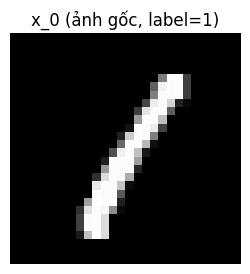

In [2]:
dataset = datasets.MNIST(
    ROOT / "data",
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

SAMPLE_INDEX = 3
label = dataset[SAMPLE_INDEX][1]
x_0 = dataset[SAMPLE_INDEX][0].unsqueeze(0) * 2 - 1  # [1, 1, 28, 28], range [-1, 1]

print("Shape x_0:", tuple(x_0.shape), "— batch, channel, height, width")
print("Label (chữ số):", label)
print("Min / max:", x_0.min().item(), x_0.max().item())

plt.figure(figsize=(3, 3))
plt.imshow((x_0.squeeze().numpy() + 1) / 2, cmap="gray", vmin=0, vmax=1)
plt.title(f"x_0 (ảnh gốc, label={label})")
plt.axis("off")
plt.show()

## 2. Noise schedule — `beta`, `alpha`, `alpha_bar`

Diffusion không thêm nhiễu “bừa bãi”: có **lịch trình** (schedule) qua `T` bước.

**Linear schedule (DDPM paper):**

- `beta_t`: lượng nhiễu thêm **ở bước t** (tăng dần từ ~0.0001 → ~0.02)
- `alpha_t = 1 - beta_t`: phần tín hiệu **giữ lại** ở bước t
- `alpha_bar_t = alpha_1 × alpha_2 × ... × alpha_t`: tích lũy — **còn bao nhiêu % ảnh gốc** sau t bước

Công thức forward (một phát, không cần lặp từng bước):

```
x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise
      └─ phần ảnh gốc ─┘   └──── phần nhiễu ngẫu nhiên ────┘
```

Trong code: `LinearSchedule.q_sample(x_0, t)` implement đúng công thức trên.

T = 1000 timesteps
beta[0]   = 0.000100  (ít nhiễu ở đầu)
beta[-1]  = 0.020000  (nhiều nhiễu ở cuối)
alpha_bar[0]   = 0.9999  → gần 1: gần như còn nguyên ảnh
alpha_bar[500] = 0.0778
alpha_bar[999] = 0.0000  → gần 0: gần như toàn nhiễu


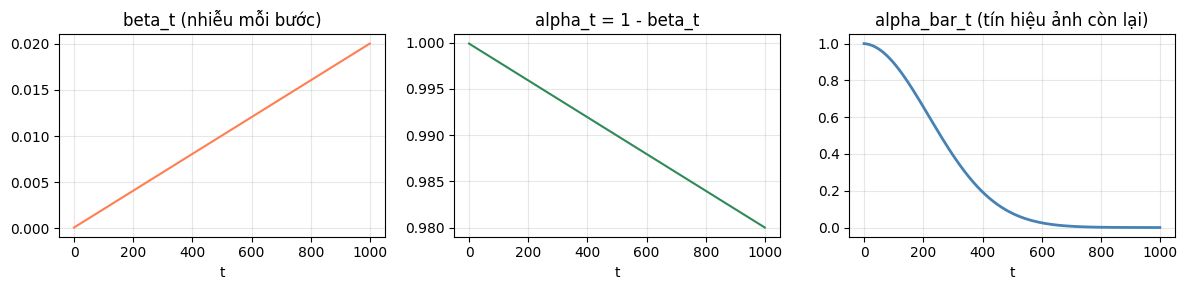

In [3]:
T = 1000
schedule = LinearSchedule(T=T)

print(f"T = {schedule.T} timesteps")
print(f"beta[0]   = {schedule.beta[0]:.6f}  (ít nhiễu ở đầu)")
print(f"beta[-1]  = {schedule.beta[-1]:.6f}  (nhiều nhiễu ở cuối)")
print(f"alpha_bar[0]   = {schedule.alpha_bar[0]:.4f}  → gần 1: gần như còn nguyên ảnh")
print(f"alpha_bar[500] = {schedule.alpha_bar[500]:.4f}")
print(f"alpha_bar[999] = {schedule.alpha_bar[999]:.4f}  → gần 0: gần như toàn nhiễu")

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].plot(schedule.beta.numpy(), color="coral")
axes[0].set_title("beta_t (nhiễu mỗi bước)")
axes[0].set_xlabel("t")
axes[0].grid(True, alpha=0.3)

axes[1].plot(schedule.alpha.numpy(), color="seagreen")
axes[1].set_title("alpha_t = 1 - beta_t")
axes[1].set_xlabel("t")
axes[1].grid(True, alpha=0.3)

axes[2].plot(schedule.alpha_bar.numpy(), color="steelblue", linewidth=2)
axes[2].set_title("alpha_bar_t (tín hiệu ảnh còn lại)")
axes[2].set_xlabel("t")
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 3. `q_sample` — tách thành phần ảnh vs nhiễu

Hàm `schedule.q_sample(x_0, t)` trả về `(x_t, noise)`.

Cell dưới **tính tay** từng thành phần để thấy:
- `signal_part = sqrt(alpha_bar) * x_0`
- `noise_part = sqrt(1 - alpha_bar) * noise`
- `x_t = signal_part + noise_part`

Khi `t` nhỏ → `alpha_bar` ≈ 1 → `x_t` giống `x_0`.  
Khi `t` lớn → `alpha_bar` ≈ 0 → `x_t` giống nhiễu Gaussian.

t = 400, alpha_bar = 0.1936
sqrt(alpha_bar)           = 0.4400
sqrt(1 - alpha_bar)       = 0.8980
Max |x_t tay - x_t lib|:   0.00e+00  (phải ~ 0)


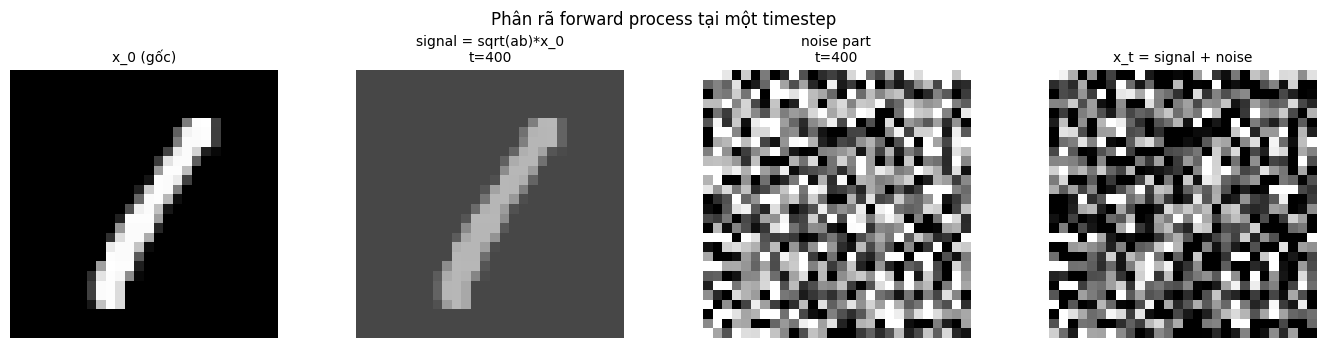

In [ ]:
def decompose_q_sample(x_0, schedule, t, noise=None):
    """Tách x_t thành phần signal + noise (minh họa công thức)."""
    if noise is None:
        noise = torch.randn_like(x_0)
    sqrt_ab = schedule.sqrt_alpha_bar[t].item()
    sqrt_1_ab = schedule.sqrt_one_minus_alpha_bar[t].item()
    signal = sqrt_ab * x_0
    noisy = sqrt_1_ab * noise
    x_t = signal + noisy
    return x_t, signal, noisy, noise


t_demo = 400
x_t, signal, noisy, noise = decompose_q_sample(x_0, schedule, t_demo)
x_t_lib, noise_lib = schedule.q_sample(x_0, torch.tensor([t_demo]), noise=noise)

print(f"t = {t_demo}, alpha_bar = {schedule.alpha_bar[t_demo]:.4f}")
print(f"sqrt(alpha_bar)           = {schedule.sqrt_alpha_bar[t_demo]:.4f}")
print(f"sqrt(1 - alpha_bar)       = {schedule.sqrt_one_minus_alpha_bar[t_demo]:.4f}")
print(f"Max |x_t tay - x_t lib|:   {(x_t - x_t_lib).abs().max().item():.2e}  (phải ~ 0)")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
panels = [
    (x_0, f"x_0 (gốc)"),
    (signal, f"signal = sqrt(ab)*x_0\nt={t_demo}"),
    (noisy, f"noise part\nt={t_demo}"),
    (x_t, f"x_t = signal + noise"),
]


# Đoạn này chỉ để show ảnh thôi, không có sử lý gì thêm đâu.
for ax, (tensor, title) in zip(axes, panels):
    img = (tensor.squeeze().numpy() + 1) / 2
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    
    
plt.suptitle("Phân rã forward process tại một timestep", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Quan sát forward process — giống `01_forward_process.py`

Script gốc vẽ ảnh cùng `x_0` tại các `t`: 0, 50, 100, 200, 400, 600, 800, 999.

**Đọc hình:**
- `t = 0`: ảnh rõ (alpha_bar ≈ 1)
- `t` tăng: chữ số mờ dần
- `t = 999`: không còn nhận ra số — gần nhiễu thuần

Đây chính là quá trình **huấn luyện** DDPM nhìn thấy: model học dự đoán `noise` trong `x_t`.

Đã lưu → /Users/nguyenkz/Documents/code/CS2309.CH201/learn/diffusion-from-scratch/assets/forward_process_notebook.png


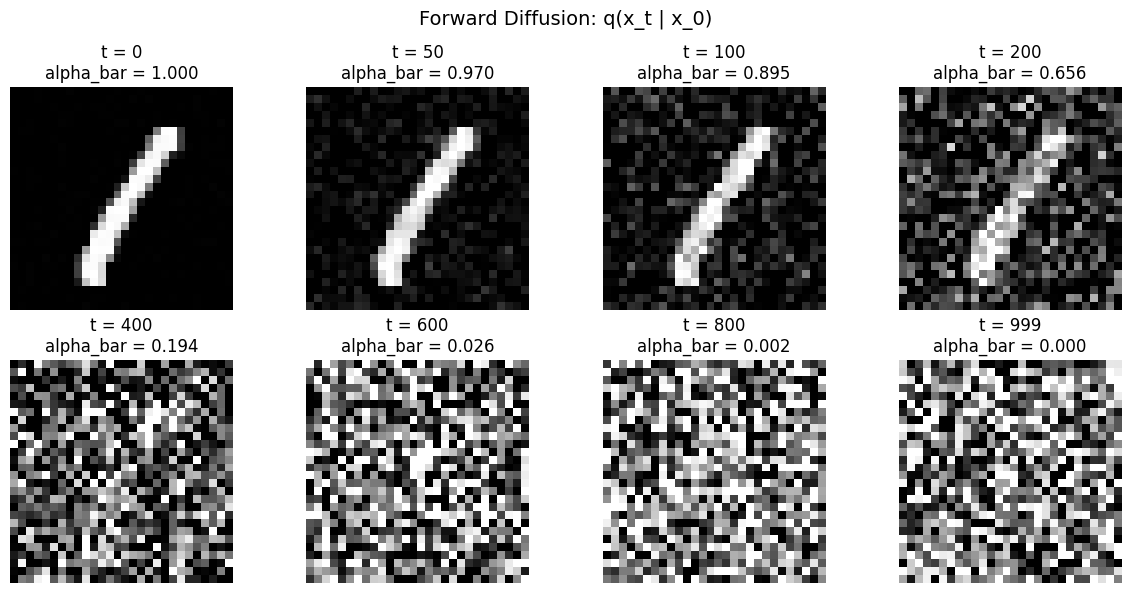

In [5]:
timesteps = [0, 50, 100, 200, 400, 600, 800, 999]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Forward Diffusion: q(x_t | x_0)", fontsize=14)

for i, t in enumerate(timesteps):
    t_tensor = torch.tensor([t])
    x_t, _ = schedule.q_sample(x_0, t_tensor)
    img = (x_t.squeeze().numpy() + 1) / 2

    ax = axes[i // 4, i % 4]
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"t = {t}\nalpha_bar = {schedule.alpha_bar[t]:.3f}")
    ax.axis("off")

fig.tight_layout()

assets_dir = ROOT / "assets"
assets_dir.mkdir(exist_ok=True)
out_path = assets_dir / "forward_process_notebook.png"
fig.savefig(out_path, dpi=150)
print(f"Đã lưu → {out_path}")
plt.show()

## 5. Đường cong `alpha_bar` — “mức sương mù” theo thời gian

Trục Y = `alpha_bar_t` = **tỉ lệ tín hiệu ảnh gốc còn lại**.

- Đầu schedule (`t` nhỏ): đường gần 1 → ảnh còn rõ
- Cuối schedule (`t` → 999): đường gần 0 → ảnh thành nhiễu

**Reverse process (bước sau):** UNet học đi **ngược** đường này — từ nhiễu (`t=999`) lau dần về ảnh (`t=0`). Forward process là “phá”; reverse là “dựng lại”.

Đã lưu → /Users/nguyenkz/Documents/code/CS2309.CH201/learn/diffusion-from-scratch/assets/noise_schedule_notebook.png


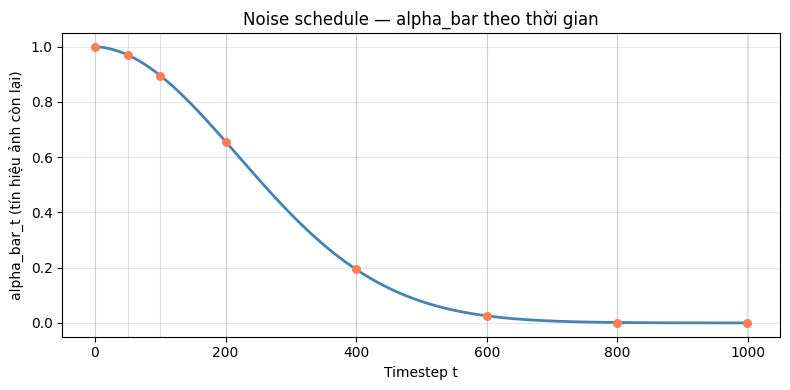

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(schedule.alpha_bar.numpy(), color="steelblue", linewidth=2)
for t in timesteps:
    ax.axvline(t, color="gray", alpha=0.25, linewidth=0.8)
    ax.scatter([t], [schedule.alpha_bar[t].item()], color="coral", s=30, zorder=3)
ax.set_xlabel("Timestep t")
ax.set_ylabel("alpha_bar_t (tín hiệu ảnh còn lại)")
ax.set_title("Noise schedule — alpha_bar theo thời gian")
ax.grid(True, alpha=0.3)
fig.tight_layout()

out_path = assets_dir / "noise_schedule_notebook.png"
fig.savefig(out_path, dpi=150)
print(f"Đã lưu → {out_path}")
plt.show()

## 6. Thử nghiệm — đổi `t` và xem ảnh (tùy chọn)

Sửa `T_TRY` rồi chạy cell. Quan sát: `alpha_bar` càng nhỏ → ảnh càng giống TV static.

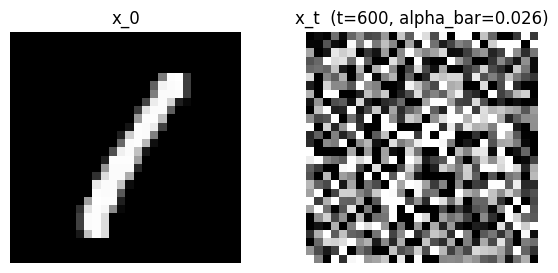

In [7]:
T_TRY = 600  # thử: 0, 100, 400, 800, 999

x_t, _ = schedule.q_sample(x_0, torch.tensor([T_TRY]))
ab = schedule.alpha_bar[T_TRY].item()

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow((x_0.squeeze().numpy() + 1) / 2, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("x_0")
axes[0].axis("off")
axes[1].imshow((x_t.squeeze().numpy() + 1) / 2, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"x_t  (t={T_TRY}, alpha_bar={ab:.3f})")
axes[1].axis("off")
plt.show()

## 7. Tóm tắt & nối sang SwiftEdit

### Bạn vừa học được

1. **Forward process** thêm nhiễu vào `x_0` theo công thức một dòng (`q_sample`).
2. **`alpha_bar_t`** điều khiển mức “sương mù” — không cần lặp 1000 bước khi tính `x_t`.
3. Huấn luyện DDPM: lấy `t` ngẫu nhiên, tạo `x_t`, UNet đoán **noise** đã cộng vào.

### Bước tiếp theo trong repo

| File | Nội dung |
|------|----------|
| `02_train_ddpm.py` | UNet học dự đoán noise (reverse học từ forward) |
| `03_sample_ddpm.py` | Sinh ảnh: nhiễu → 1000 bước denoise |
| `04_sample_ddim.py` | Cùng model, chỉ ~50 bước (giống pipeline editing cũ) |

### SwiftEdit (đề tài CS2309)

- **Không** chạy 1000-step forward khi edit ảnh thật.
- Method cũ: **inversion** = đi ngược forward (nhiều step DDIM) để tìm noise từ ảnh.
- **SwiftEdit:** mạng `F_theta` ánh xạ ảnh → inverted noise **1 forward pass**.

**Checklist hiểu bài (tự kiểm):**

- [ ] Giải thích được `x_t = sqrt(alpha_bar)*x_0 + sqrt(1-alpha_bar)*noise`
- [ ] Biết `alpha_bar` giảm nghĩa là gì
- [ ] Phân biệt forward (phá ảnh) vs reverse (dựng ảnh / denoise)

→ Xong thì quay lại [`tasks/theory_tasks.md`](../../tasks/theory_tasks.md) Task 1.